# Сверточные нейронные сети (ноутбук)

> Знакомимся со сверточными нейронными сетями. Учимся решать задачу классификации изображений.

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms.v2 as T
from IPython.display import clear_output
from PIL import Image
from matplotlib import cm
from time import perf_counter
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from tqdm import tqdm

warnings.filterwarnings('ignore')

plt.rc('font', size=30)

## Загрузка изображения

Загрузим изображение из интернета, например, Питер Гриффина из одноименного мультсериала "Гриффины".

In [ ]:
! wget "https://cs13.pikabu.ru/post_img/big/2023/09/11/5/1694416670162565263.jpg" -O kitty.jpg

--2024-11-07 18:03:42--  https://cs13.pikabu.ru/post_img/big/2023/09/11/5/1694416670162565263.jpg
Resolving cs13.pikabu.ru (cs13.pikabu.ru)... 185.178.210.195
Connecting to cs13.pikabu.ru (cs13.pikabu.ru)|185.178.210.195|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 244167 (238K) [image/jpeg]
Saving to: ‘kitty.jpg’

kitty.jpg           100%[===================>] 238.44K   434KB/s    in 0.5s    

2024-11-07 18:03:43 (434 KB/s) - ‘kitty.jpg’ saved [244167/244167]



## Чтение изображения

In [ ]:
img = Image.open('kitty.jpg')

In [ ]:
img.format

'JPEG'

In [ ]:
img.size

(736, 981)

In [ ]:
img.mode

'RGB'

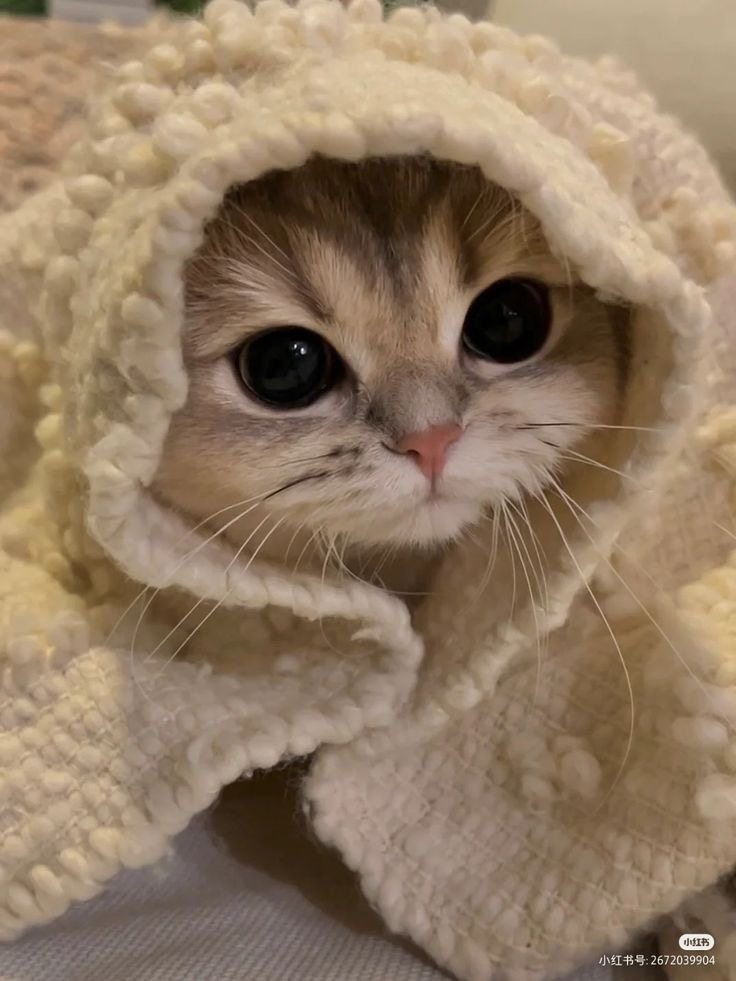

In [ ]:
img

## Матричное представление

In [ ]:
img_matrix = np.array(img)

In [ ]:
img_matrix.shape

(981, 736, 3)

array([[[ 66,  75,  44],
        [ 66,  75,  44],
        [ 65,  74,  43],
        ...,
        [193, 173, 146],
        [193, 173, 146],
        [193, 173, 146]],

       [[ 67,  76,  45],
        [ 67,  76,  45],
        [ 66,  75,  44],
        ...,
        [193, 173, 146],
        [193, 173, 146],
        [193, 173, 146]],

       [[ 68,  79,  49],
        [ 67,  78,  48],
        [ 66,  77,  47],
        ...,
        [192, 172, 145],
        [192, 172, 145],
        [192, 172, 145]],

       ...,

       [[170, 150, 139],
        [171, 151, 140],
        [171, 151, 140],
        ...,
        [141, 120,  93],
        [144, 123,  96],
        [144, 123,  96]],

       [[169, 149, 138],
        [171, 151, 140],
        [171, 151, 140],
        ...,
        [143, 122,  95],
        [143, 122,  95],
        [145, 124,  97]],

       [[166, 146, 135],
        [169, 149, 138],
        [170, 151, 137],
        ...,
        [140, 119,  92],
        [145, 124,  97],
        [145, 124,  97]]], dtype=uint8)
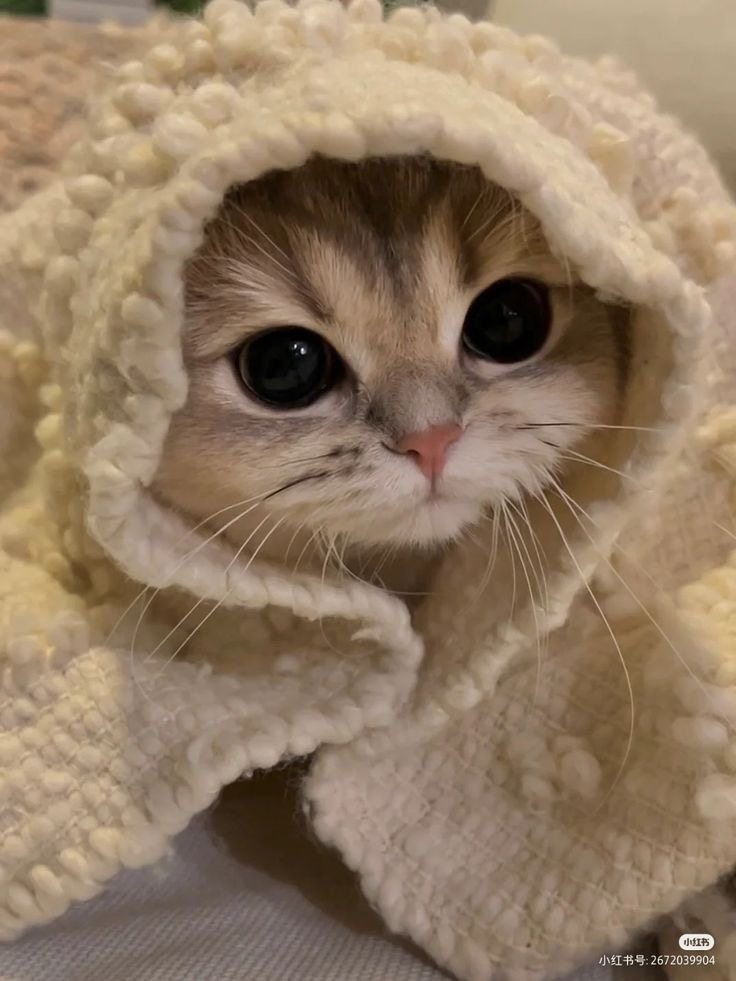

In [ ]:
img_matrix

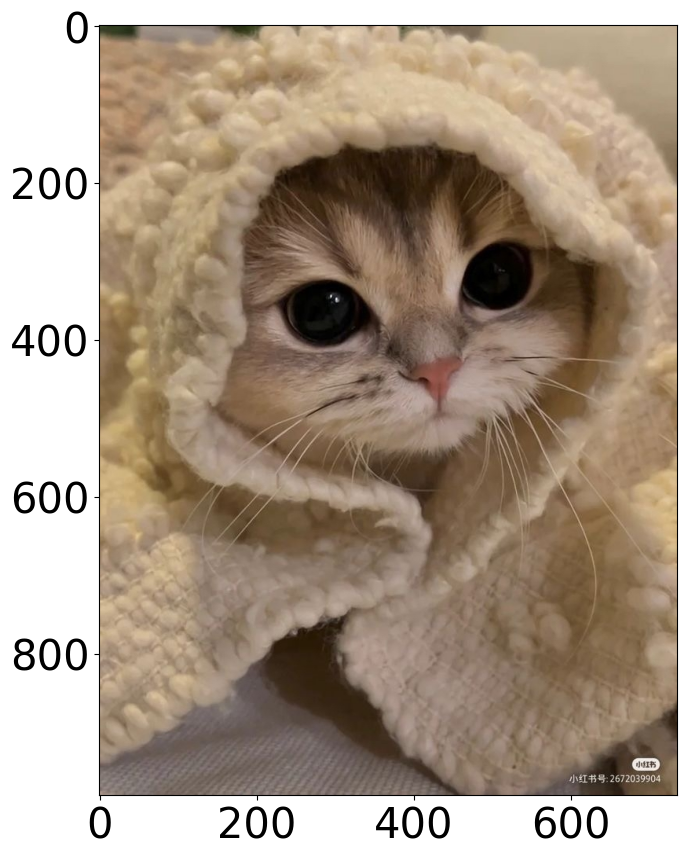

In [ ]:
plt.figure(figsize=(20, 10))

plt.imshow(img_matrix)

plt.show()

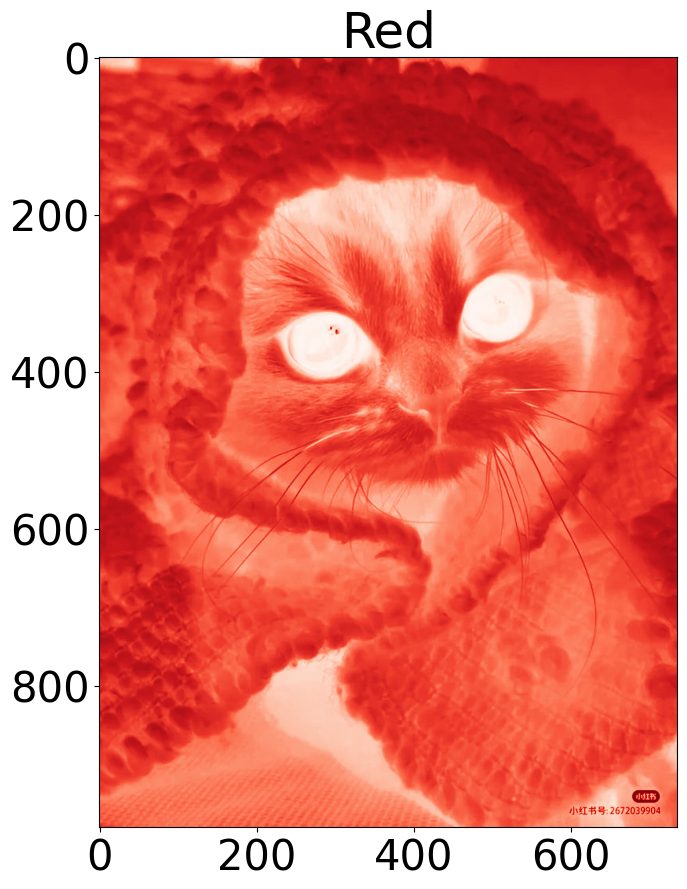

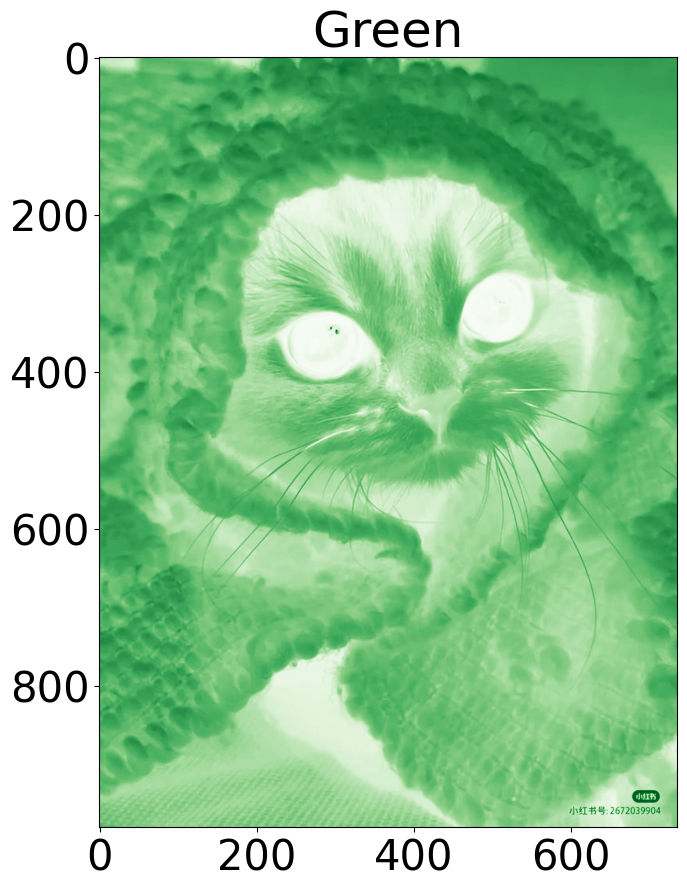

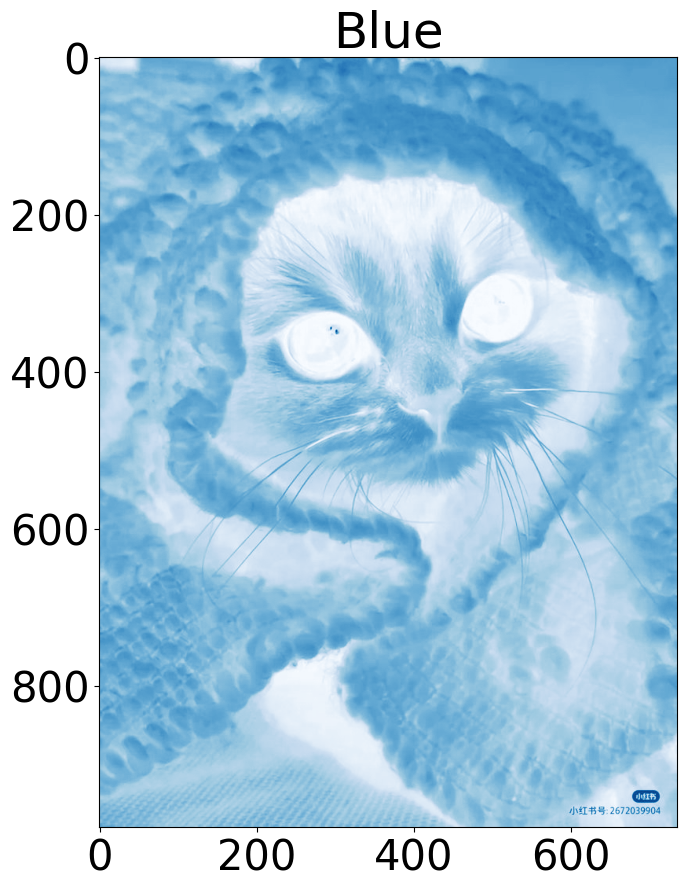

In [ ]:
for i, (cmap, color) in enumerate(
    zip(
        [cm.Reds, cm.Greens, cm.Blues],
        ['Red', 'Green', 'Blue']
    )
):
    plt.figure(figsize=(20, 10))
    plt.imshow(img_matrix[:, :, i], cmap=cmap)
    plt.title(color)
    plt.show()

In [ ]:
img_matrix.min(), img_matrix.max()

(0, 255)

## Свертка

Свертка в `PyTorch` представлена модулем `nn.Conv2d` со следующими параметрами:

- in_channels (int) – Количество каналов во входном изображении

- out_channels (int) – Количество каналов в выходном изображении

- kernel_size (int or tuple) – Размер ядра свертки

- stride (int or tuple, optional) – Страйд (шаг ядра свертки). По умолчанию: 1

- padding (int, tuple or str, optional) – Размер паддинга. По умолчанию: 0

- padding_mode (string, optional) – 'zeros', 'reflect', 'replicate' or 'circular'. По умолчанию: 'zeros'

- dilation (int or tuple, optional) – Дилейшн (шаг между элементами внутри ядра). По умолчанию: 1

- bias (bool, optional) – добавлять ли обучаемый сдвиг. По умолчанию: True

https://ezyang.github.io/convolution-visualizer/

In [ ]:
conv1 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3
)

In [ ]:
img_tensor = T.ToTensor()(img).unsqueeze(0)

In [ ]:
img_tensor.shape

torch.Size([1, 3, 981, 736])

In [ ]:
output = conv1(img_tensor)

In [ ]:
output.shape

torch.Size([1, 10, 979, 734])

In [ ]:
conv2 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=5,
    padding=1
)

In [ ]:
output = conv2(img_tensor)

In [ ]:
output.shape

torch.Size([1, 10, 979, 734])

In [ ]:
conv2.weight.shape

torch.Size([10, 3, 5, 5])

In [ ]:
conv2.bias.shape

torch.Size([10])

## Пулинг

Пулинг представлен в модуле `torch.nn`, в основном будем использовать `MaxPool2d` и `AvgPool2d`.

Параметры:

- kernel_size – размер окошка

- stride – страйд окошка. По умолчанию равен kernel_size

- padding – сколько нулевого паддинга добавлять по краям. По умолчанию: 0.

In [ ]:
img_tensor = torch.randint(0, 10, size=(10, 10), dtype=torch.float32).unsqueeze(0)

In [ ]:
img_tensor

tensor([[[8., 0., 8., 9., 0., 5., 4., 3., 7., 5.],
         [1., 3., 6., 6., 6., 8., 0., 7., 5., 7.],
         [9., 5., 7., 1., 0., 0., 8., 1., 2., 9.],
         [6., 6., 6., 8., 6., 3., 4., 8., 6., 3.],
         [9., 3., 8., 8., 3., 3., 3., 7., 6., 1.],
         [0., 0., 4., 4., 7., 9., 6., 6., 1., 2.],
         [7., 8., 1., 2., 3., 3., 3., 8., 4., 6.],
         [4., 8., 2., 2., 2., 8., 2., 1., 6., 9.],
         [2., 2., 3., 7., 2., 8., 1., 9., 5., 6.],
         [9., 5., 0., 5., 4., 8., 3., 8., 9., 4.]]])

In [ ]:
pooling1 = nn.MaxPool2d(kernel_size=2)

In [ ]:
pooling1(img_tensor)

tensor([[[8., 9., 8., 7., 7.],
         [9., 8., 6., 8., 9.],
         [9., 8., 9., 7., 6.],
         [8., 2., 8., 8., 9.],
         [9., 7., 8., 9., 9.]]])

In [ ]:
pooling2 = nn.AvgPool2d(kernel_size=2)

In [ ]:
pooling2(img_tensor)

tensor([[[3.0000, 7.2500, 4.7500, 3.5000, 6.0000],
         [6.5000, 5.5000, 2.2500, 5.2500, 5.0000],
         [3.0000, 6.0000, 5.5000, 5.5000, 2.5000],
         [6.7500, 1.7500, 4.0000, 3.5000, 6.2500],
         [4.5000, 3.7500, 5.5000, 5.2500, 6.0000]]])

## Датасет MNIST

In [ ]:
mnist_train = MNIST(
    "../datasets/mnist",
    train=True,
    download=True,
    transform=T.ToTensor()
)

In [ ]:
mnist_valid = MNIST(
    "../datasets/mnist",
    train=False,
    download=True,
    transform=T.ToTensor()
)

In [ ]:
len(mnist_train)

60000

In [ ]:
len(mnist_valid)

10000

In [ ]:
mnist_train[0][0].shape, mnist_train[0][1]

(torch.Size([1, 28, 28]), 5)

In [ ]:
train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True, num_workers=2)
valid_loader = DataLoader(mnist_valid, batch_size=64, shuffle=False, num_workers=2)

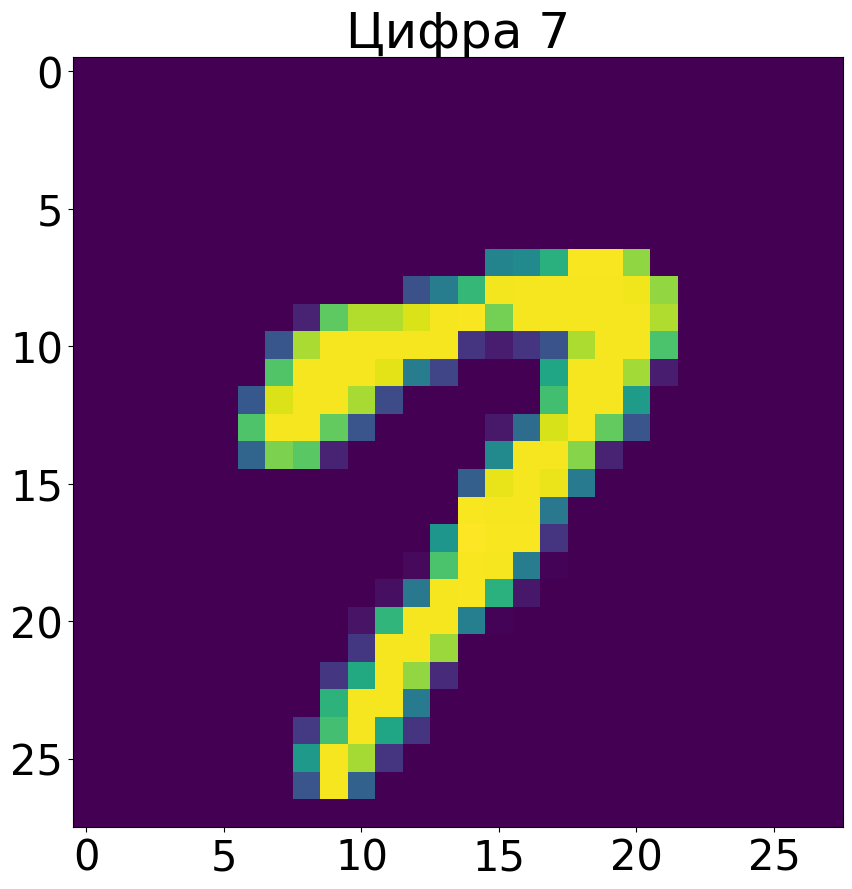

In [ ]:
plt.figure(figsize=(10, 10))
plt.title(f'Цифра {mnist_train[15][1]}')
plt.imshow(mnist_train[15][0][0])

plt.show()

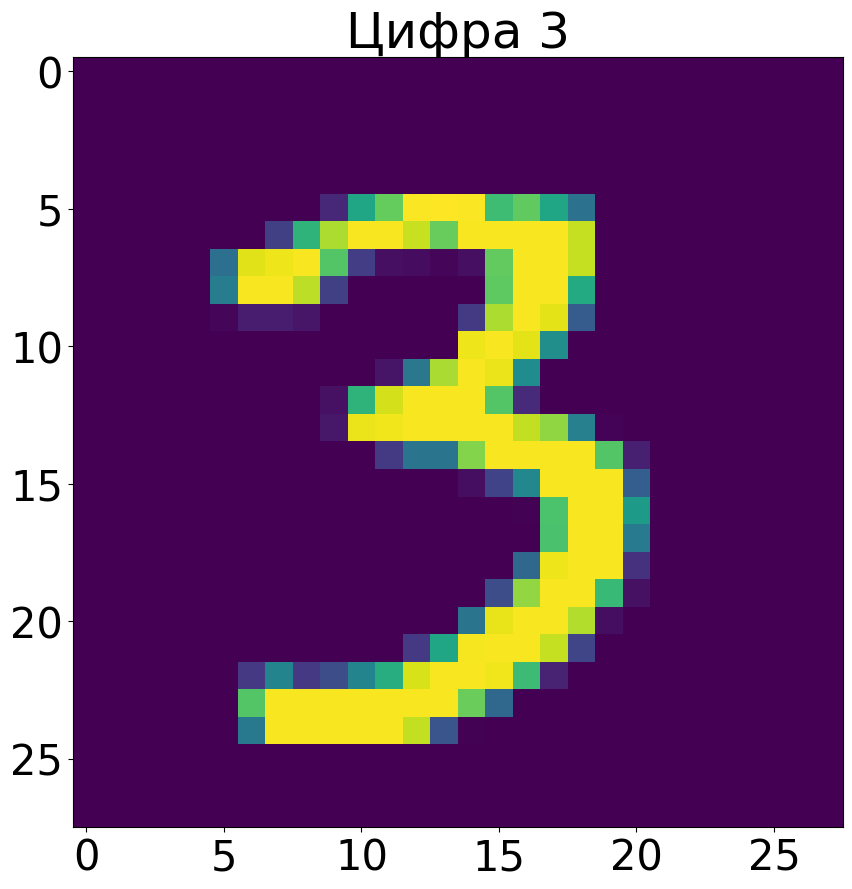

In [ ]:
plt.figure(figsize=(10, 10))
plt.title(f'Цифра {mnist_train[10000][1]}')
plt.imshow(mnist_train[10000][0][0])

plt.show()

## Полносвязная нейронная сеть

Обучим полносвязную нейронную сеть на датасете MNIST.

In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Optimizer


def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, loss_fn):
    model.train()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        output = model(x)
        loss = loss_fn(output, y)
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        total_correct += (output.argmax(dim=1) == y).sum().item()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn):
    model.eval()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        with torch.inference_mode():
            output = model(x)
            loss = loss_fn(output, y)

        total_loss += loss.item()
        total_correct += (output.argmax(dim=1) == y).sum().item()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style='darkgrid')


def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')

    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()

    plt.show()

In [ ]:
from IPython.display import clear_output


def fit(model, train_loader, valid_loader, optimizer, loss_fn, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, loss_fn)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

In [ ]:
first_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

optimizer = torch.optim.Adam(first_model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

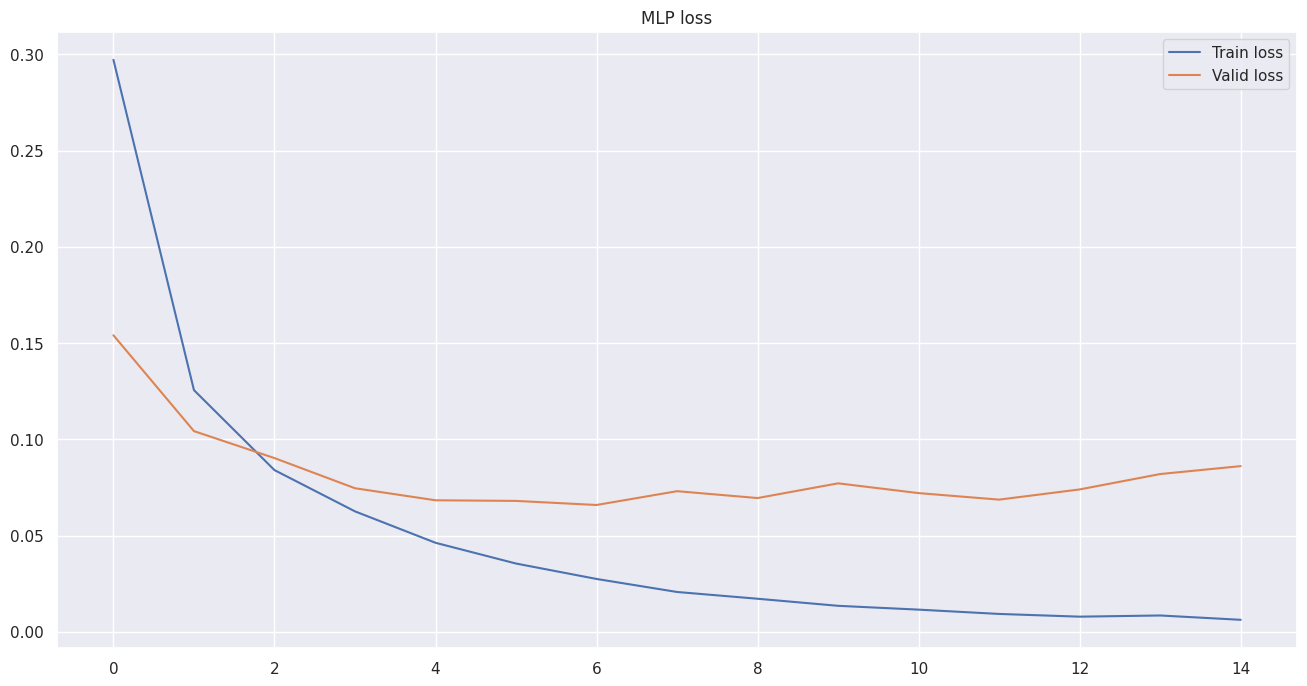

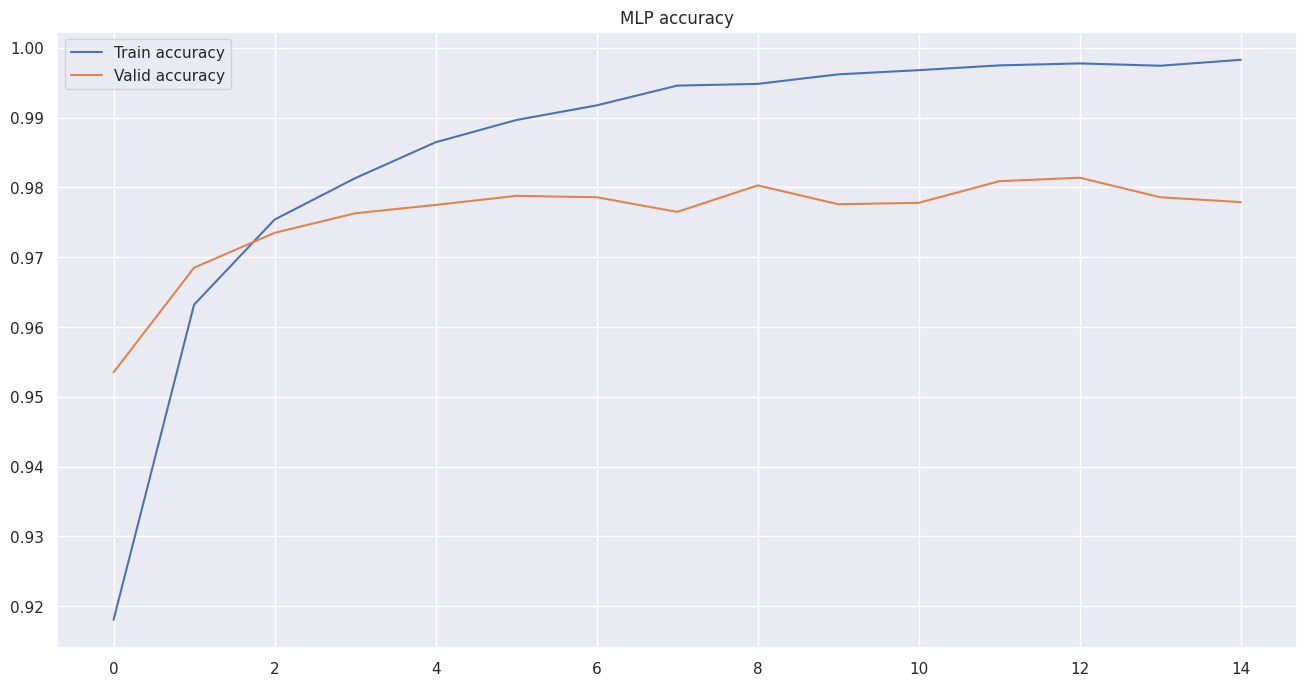

In [ ]:
fit(first_model, train_loader, valid_loader, optimizer, loss_fn, 15, 'MLP')

## Сверточная сеть

In [ ]:
second_model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5),  # 28 x 28 -> 24 x 24
    nn.LeakyReLU(),
    nn.MaxPool2d(kernel_size=2),  # 24 x 24 -> 12 x 12

    nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5),  # 12 x 12 -> 8 x 8
    nn.LeakyReLU(),
    nn.MaxPool2d(kernel_size=2),  # 8 x 8 -> 4 x 4

    nn.Flatten(),  # 4 x 4 x 16 -> 4 * 4 * 16
    nn.Linear(4 * 4 * 16, 100),
    nn.LeakyReLU(),
    nn.Linear(100, 10)
)

optimizer = torch.optim.Adam(second_model.parameters(), lr=1e-3)

loss_fn = nn.CrossEntropyLoss()

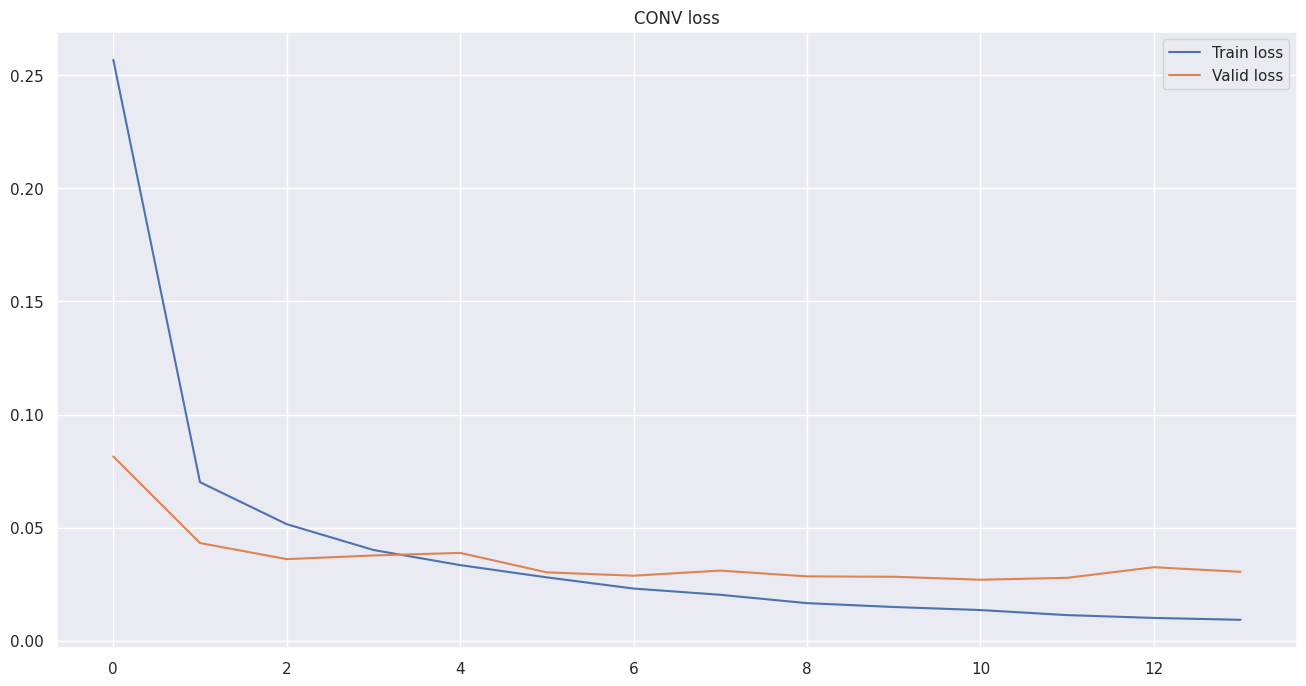

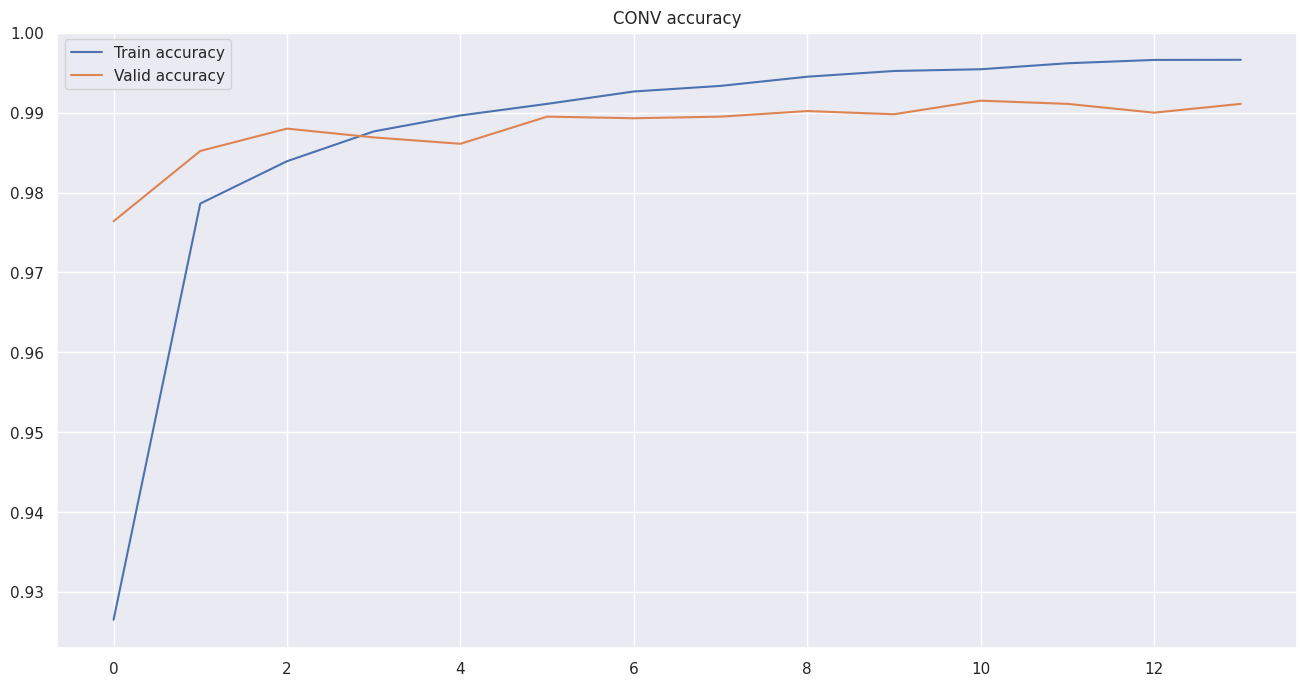

 19%|█▉        | 178/938 [00:03<00:12, 59.30it/s]


KeyboardInterrupt: 

In [ ]:
fit(second_model, train_loader, valid_loader, optimizer, loss_fn, 15, 'CONV')